# Fase 6 -- Evaluacion + interpretabilidad TreeSHAP

**Notebook**: `08_evaluacion_shap.ipynb`
**Plan**: Fase 6 (`PLAN_DE_TRABAJO.md` Seccion FASE 6)
**Inputs**:
- `data/processed/nacional_test.csv` (50,957 x 77, ANIO 2023-2024)
- `models/{logistic_regression,random_forest,xgboost,xgboost_smote}.joblib`
- `reports/metrics/best_hyperparams.json`

**Outputs**:
- `reports/metrics/test_metrics.json`
- `reports/figures/08_matriz_confusion_xgboost.png`
- `reports/figures/09_curvas_roc_pr.png`
- `reports/figures/10_comparacion_modelos.png`
- `reports/figures/11_shap_beeswarm.png`
- `reports/figures/12_shap_importance_bar.png`
- `reports/figures/13_shap_waterfall_ejemplos.png`
- `reports/tables/metricas_test_por_modelo.tex`

> **Nota de numeracion**: el plan original asignaba 07-12 a las figuras de Fase 6,
> pero la Fase 4 ya consumio `07_distribucion_clases_por_split.png`. Para no pisar
> ese archivo se desplazan +1 (08-13). Las fases siguientes deberan reajustar.

**Criterios de aceptacion** (PLAN 6.3):
- F1-macro >= 0.70 sobre test (esperable dado N grande).
- Top features SHAP consistentes con literatura (cobertura_intereses, razon_deuda, margen_neto -- SoTA v2 §3.4).
- 9 waterfall plots se generan correctamente (3 ejemplos x 3 clases).

**Decisiones operativas**:
1. **Mejor modelo = XGBoost (sample_weight)** -- gano en val (F1=0.9979) con gap minimo.
2. **SHAP sobre 5,000 obs estratificadas** del test (~10% del test, suficiente para Beeswarm
   estable; TreeSHAP es exacto en arboles).
3. **AUC-ROC OvR (One-vs-Rest)** y **AUC-PR macro** para multiclass.
4. **Matriz de confusion** normalizada por fila (recall por clase = diagonal).
5. **Reproducibilidad**: `random_state=42` para muestreos.


In [1]:
from __future__ import annotations
import json
import sys
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap
from matplotlib.colors import LinearSegmentedColormap
from sklearn.metrics import (
    accuracy_score, average_precision_score, classification_report,
    confusion_matrix, f1_score, precision_recall_curve, precision_recall_fscore_support,
    roc_auc_score, roc_curve,
)

np.random.seed(42)
RANDOM_STATE = 42

ROOT = Path('..').resolve()
sys.path.insert(0, str(ROOT))
DATA_PROCESSED = ROOT / 'data' / 'processed'
MODELS = ROOT / 'models'
REPORTS = ROOT / 'reports'
FIGURES = REPORTS / 'figures'
TABLES = REPORTS / 'tables'
METRICS = REPORTS / 'metrics'
for d in (FIGURES, TABLES, METRICS):
    d.mkdir(parents=True, exist_ok=True)

warnings.filterwarnings('ignore', category=UserWarning)
warnings.filterwarnings('ignore', category=FutureWarning)

import sklearn, xgboost
print('python', sys.version.split()[0])
print('sklearn', sklearn.__version__)
print('xgboost', xgboost.__version__)
print('shap', shap.__version__)
print('seed:', RANDOM_STATE)


python 3.14.4
sklearn 1.8.0
xgboost 3.2.0
shap 0.51.0
seed: 42


## 1. Cargar test set + modelos

Cargamos el test (50,957 obs ANIO 2023-2024, sin Ibague) y los 4 modelos
serializados en Fase 5. La meta-info (`feature_cols`, `label_encoder_classes`)
viaja dentro de cada artefacto joblib (verificado en notebook 07).


In [2]:
# Cargar test
df_test = pd.read_csv(DATA_PROCESSED / 'nacional_test.csv',
                      low_memory=False, dtype={'NIT_LIMPIO': str})
print(f'Test: {df_test.shape}')
print(f'Anyos en test: {sorted(df_test["ANIO"].unique().tolist())}')

# Cargar modelos
artefactos = {}
for nombre in ['logistic_regression', 'random_forest', 'xgboost', 'xgboost_smote']:
    artefactos[nombre] = joblib.load(MODELS / f'{nombre}.joblib')
print(f'Modelos cargados: {list(artefactos.keys())}')

# Recuperar columnas de feature y clases del LR (todas tienen la misma meta)
META = artefactos['logistic_regression']['meta']
FEATURE_COLS = META['feature_cols']
CLASSES = META['label_encoder_classes']  # alfabetico: ['riesgo_alto','riesgo_bajo','riesgo_medio']
N_CLASSES = len(CLASSES)
print(f'\nFeatures ML: {len(FEATURE_COLS)}')
print(f'Clases (orden alfabetico LabelEncoder): {CLASSES}')


Test: (50957, 77)
Anyos en test: [2023, 2024]


Modelos cargados: ['logistic_regression', 'random_forest', 'xgboost', 'xgboost_smote']

Features ML: 71
Clases (orden alfabetico LabelEncoder): ['riesgo_alto', 'riesgo_bajo', 'riesgo_medio']


In [3]:
# Construir X_test, y_test
X_test = df_test[FEATURE_COLS].astype(np.float64).values
y_test_str = df_test['etiqueta_final'].values

# Recodificar y_test al orden alfabetico (compat. con LabelEncoder de Fase 5)
clase_a_idx = {c: i for i, c in enumerate(CLASSES)}
y_test = np.array([clase_a_idx[c] for c in y_test_str])

print(f'X_test: {X_test.shape}  y_test: {y_test.shape}')
print(f'% NaN promedio en X_test: {np.isnan(X_test).mean()*100:.2f}%')
print(f'\nDistribucion clases (test):')
for c, i in clase_a_idx.items():
    n = int((y_test == i).sum())
    print(f'  [{i}] {c:<14} n={n:>6,} ({n/len(y_test)*100:.2f}%)')


X_test: (50957, 71)  y_test: (50957,)
% NaN promedio en X_test: 6.82%

Distribucion clases (test):
  [0] riesgo_alto    n= 8,403 (16.49%)
  [1] riesgo_bajo    n=10,723 (21.04%)
  [2] riesgo_medio   n=31,831 (62.47%)


## 2. Helpers de prediccion

Cada modelo tiene una API distinta:
- **LR / RF**: `obj["pipeline"].predict(X)` y `predict_proba(X)`.
- **XGB puro**: `obj["model"].predict(X)` (XGBoost maneja NaN nativo).
- **XGB+SMOTE**: hay que imputar primero con `obj["imputer"]`.

Definimos un wrapper para uniformizar: `predecir(modelo_nombre, X)` -> `(y_pred, proba)`.


In [4]:
def predecir(nombre, X):
    art = artefactos[nombre]
    if nombre in ('logistic_regression', 'random_forest'):
        pipe = art['pipeline']
        return pipe.predict(X), pipe.predict_proba(X)
    elif nombre == 'xgboost':
        m = art['model']
        return m.predict(X), m.predict_proba(X)
    elif nombre == 'xgboost_smote':
        imp = art['imputer']; m = art['model']
        Ximp = imp.transform(X)
        return m.predict(Ximp), m.predict_proba(Ximp)
    raise ValueError(nombre)


# Generar predicciones sobre test para los 4 modelos
preds = {}
for nombre in artefactos:
    yhat, proba = predecir(nombre, X_test)
    preds[nombre] = {'y_pred': yhat, 'proba': proba}
    print(f'  {nombre:<22} y_pred={yhat.shape}, proba={proba.shape}')


  logistic_regression    y_pred=(50957,), proba=(50957, 3)


  random_forest          y_pred=(50957,), proba=(50957, 3)
  xgboost                y_pred=(50957,), proba=(50957, 3)


  xgboost_smote          y_pred=(50957,), proba=(50957, 3)


## 3. Metricas globales sobre test (los 4 modelos)

Para cada modelo:
- **Accuracy**: tasa de aciertos.
- **F1-macro**: media simple de F1 por clase (insensible al desbalance).
- **F1-weighted**: media ponderada por soporte (sensible al desbalance).
- **AUC-ROC OvR macro**: area bajo ROC promediada one-vs-rest sobre 3 clases.
- **AUC-PR macro**: area bajo Precision-Recall promediada sobre 3 clases.


In [5]:
def metricas_globales(y_true, y_pred, proba):
    return {
        'accuracy': float(accuracy_score(y_true, y_pred)),
        'f1_macro': float(f1_score(y_true, y_pred, average='macro')),
        'f1_weighted': float(f1_score(y_true, y_pred, average='weighted')),
        'auc_roc_ovr_macro': float(roc_auc_score(
            y_true, proba, multi_class='ovr', average='macro')),
        'auc_pr_macro': float(np.mean([
            average_precision_score((y_true == k).astype(int), proba[:, k])
            for k in range(N_CLASSES)
        ])),
    }


globales = {nombre: metricas_globales(y_test, preds[nombre]['y_pred'],
                                       preds[nombre]['proba'])
            for nombre in artefactos}

resumen = pd.DataFrame(globales).T.round(4)
resumen.index.name = 'modelo'
resumen = resumen.sort_values('f1_macro', ascending=False)
print('Metricas globales sobre TEST (orden: F1-macro descendente):\n')
print(resumen.to_string())


Metricas globales sobre TEST (orden: F1-macro descendente):

                     accuracy  f1_macro  f1_weighted  auc_roc_ovr_macro  auc_pr_macro
modelo                                                                               
xgboost                0.9975    0.9972       0.9975             1.0000        1.0000
xgboost_smote          0.9962    0.9956       0.9962             1.0000        0.9999
random_forest          0.9950    0.9943       0.9950             0.9999        0.9998
logistic_regression    0.8210    0.8105       0.8239             0.9533        0.8932


## 4. Reporte por clase (los 4 modelos)

Para cada modelo, precision/recall/F1/support por clase usando
`sklearn.metrics.classification_report`.


In [6]:
reportes_clase = {}
for nombre in artefactos:
    rep = classification_report(y_test, preds[nombre]['y_pred'],
                                target_names=CLASSES, digits=4,
                                zero_division=0, output_dict=True)
    reportes_clase[nombre] = {
        c: {
            'precision': float(rep[c]['precision']),
            'recall': float(rep[c]['recall']),
            'f1': float(rep[c]['f1-score']),
            'support': int(rep[c]['support']),
        }
        for c in CLASSES
    }

# Mostrar reporte del mejor modelo
mejor_modelo = resumen.index[0]
print(f'Mejor modelo (F1-macro test): {mejor_modelo}\n')
print(f'Reporte por clase ({mejor_modelo}):')
for c in CLASSES:
    r = reportes_clase[mejor_modelo][c]
    print(f'  {c:<14} P={r["precision"]:.4f} R={r["recall"]:.4f} '
          f'F1={r["f1"]:.4f} (n={r["support"]:,})')


Mejor modelo (F1-macro test): xgboost

Reporte por clase (xgboost):
  riesgo_alto    P=0.9966 R=0.9985 F1=0.9975 (n=8,403)
  riesgo_bajo    P=0.9967 R=0.9953 F1=0.9960 (n=10,723)
  riesgo_medio   P=0.9980 R=0.9980 F1=0.9980 (n=31,831)


## 5. Figura 08 -- Matriz de confusion del mejor modelo

Normalizada por fila (la diagonal es el recall por clase). Heatmap
con anotaciones de % y conteo bruto.


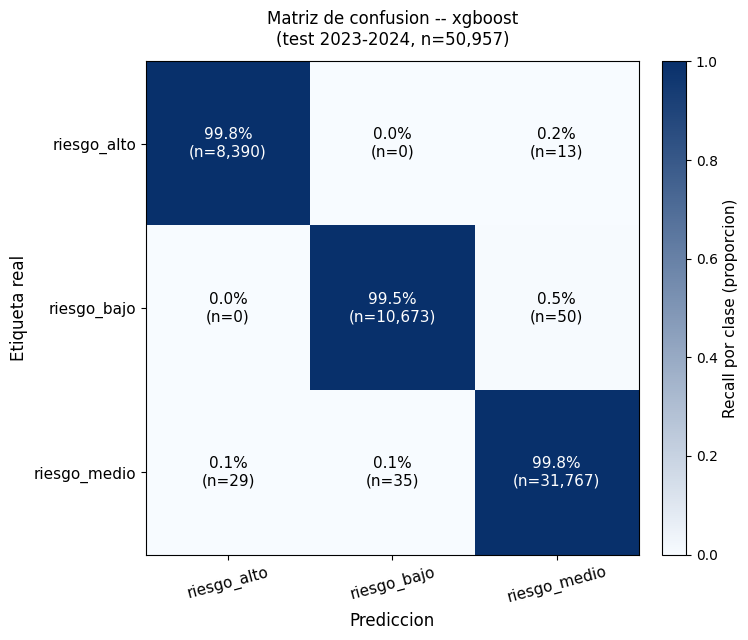

Figura guardada: reports/figures/08_matriz_confusion_xgboost.png (224.2 KB)


In [7]:
y_pred_mejor = preds[mejor_modelo]['y_pred']
cm_counts = confusion_matrix(y_test, y_pred_mejor)
cm_norm = cm_counts / cm_counts.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(7.5, 6.5))
cmap = LinearSegmentedColormap.from_list('custom_blues', ['#f7fbff', '#08306b'])
im = ax.imshow(cm_norm, cmap=cmap, vmin=0, vmax=1, aspect='equal')
cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('Recall por clase (proporcion)', fontsize=11)

ax.set_xticks(range(N_CLASSES))
ax.set_yticks(range(N_CLASSES))
ax.set_xticklabels(CLASSES, rotation=15, fontsize=11)
ax.set_yticklabels(CLASSES, fontsize=11)
ax.set_xlabel('Prediccion', fontsize=12)
ax.set_ylabel('Etiqueta real', fontsize=12)
ax.set_title(f'Matriz de confusion -- {mejor_modelo}\n'
             f'(test 2023-2024, n={len(y_test):,})', fontsize=12, pad=12)

for i in range(N_CLASSES):
    for j in range(N_CLASSES):
        color = 'white' if cm_norm[i, j] > 0.5 else 'black'
        ax.text(j, i, f'{cm_norm[i,j]*100:.1f}%\n(n={cm_counts[i,j]:,})',
                ha='center', va='center', color=color, fontsize=11)

plt.tight_layout()
ruta = FIGURES / '08_matriz_confusion_xgboost.png'
plt.savefig(ruta, dpi=300, bbox_inches='tight')
plt.show()
print(f'Figura guardada: {ruta.relative_to(ROOT)} ({ruta.stat().st_size/1024:.1f} KB)')


## 6. Figura 09 -- Curvas ROC y PR (multipanel)

Para los 4 modelos: ROC OvR (3 clases) y PR (3 clases) en una figura 2x4.


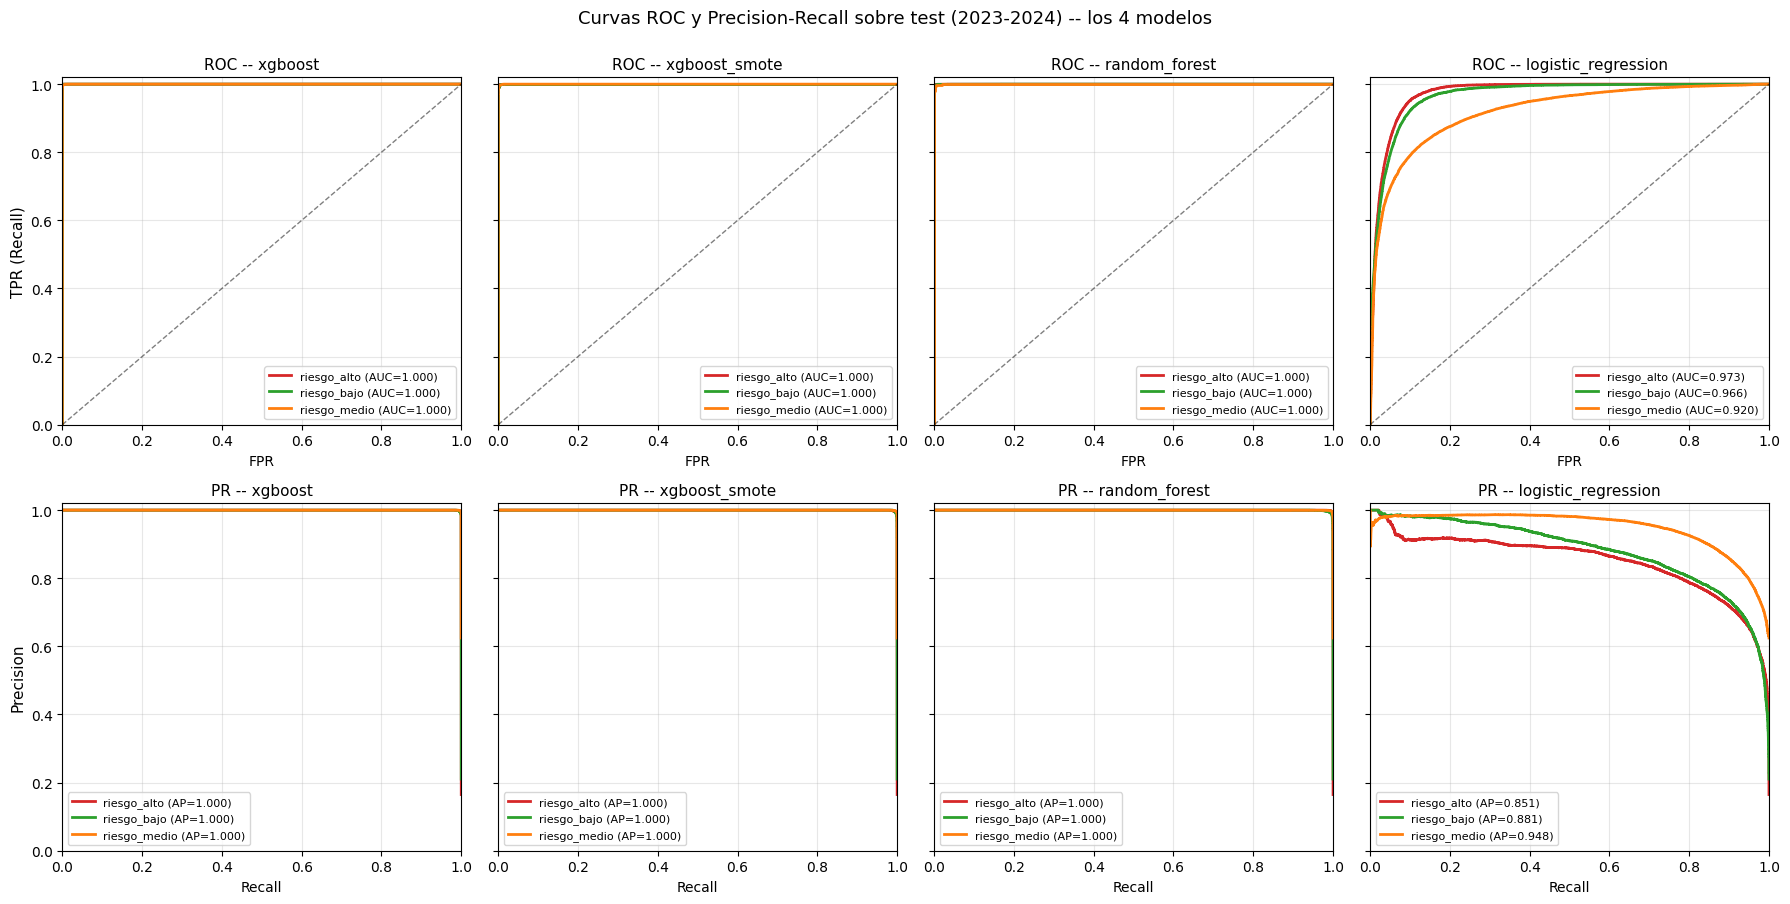

Figura guardada: reports/figures/09_curvas_roc_pr.png (466.9 KB)


In [8]:
fig, axes = plt.subplots(2, 4, figsize=(18, 9), sharey='row')
modelos_orden = list(resumen.index)
colores_clase = {'riesgo_alto': '#d62728', 'riesgo_bajo': '#2ca02c',
                  'riesgo_medio': '#ff7f0e'}

for col, nombre in enumerate(modelos_orden):
    proba = preds[nombre]['proba']
    # ROC
    ax = axes[0, col]
    for k, c in enumerate(CLASSES):
        fpr, tpr, _ = roc_curve((y_test == k).astype(int), proba[:, k])
        auc = roc_auc_score((y_test == k).astype(int), proba[:, k])
        ax.plot(fpr, tpr, color=colores_clase[c], lw=2,
                label=f'{c} (AUC={auc:.3f})')
    ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5)
    ax.set_xlim([0, 1]); ax.set_ylim([0, 1.02])
    ax.set_xlabel('FPR', fontsize=10)
    if col == 0:
        ax.set_ylabel('TPR (Recall)', fontsize=11)
    ax.set_title(f'ROC -- {nombre}', fontsize=11)
    ax.legend(loc='lower right', fontsize=8)
    ax.grid(alpha=0.3)

    # PR
    ax = axes[1, col]
    for k, c in enumerate(CLASSES):
        prec, rec, _ = precision_recall_curve((y_test == k).astype(int),
                                                proba[:, k])
        ap = average_precision_score((y_test == k).astype(int), proba[:, k])
        ax.plot(rec, prec, color=colores_clase[c], lw=2,
                label=f'{c} (AP={ap:.3f})')
    ax.set_xlim([0, 1]); ax.set_ylim([0, 1.02])
    ax.set_xlabel('Recall', fontsize=10)
    if col == 0:
        ax.set_ylabel('Precision', fontsize=11)
    ax.set_title(f'PR -- {nombre}', fontsize=11)
    ax.legend(loc='lower left', fontsize=8)
    ax.grid(alpha=0.3)

fig.suptitle('Curvas ROC y Precision-Recall sobre test (2023-2024) -- los 4 modelos',
             fontsize=13, y=1.00)
plt.tight_layout()
ruta = FIGURES / '09_curvas_roc_pr.png'
plt.savefig(ruta, dpi=300, bbox_inches='tight')
plt.show()
print(f'Figura guardada: {ruta.relative_to(ROOT)} ({ruta.stat().st_size/1024:.1f} KB)')


## 7. Figura 10 -- Comparacion de modelos (barras agrupadas)

Precision / Recall / F1 por clase para los 4 modelos.


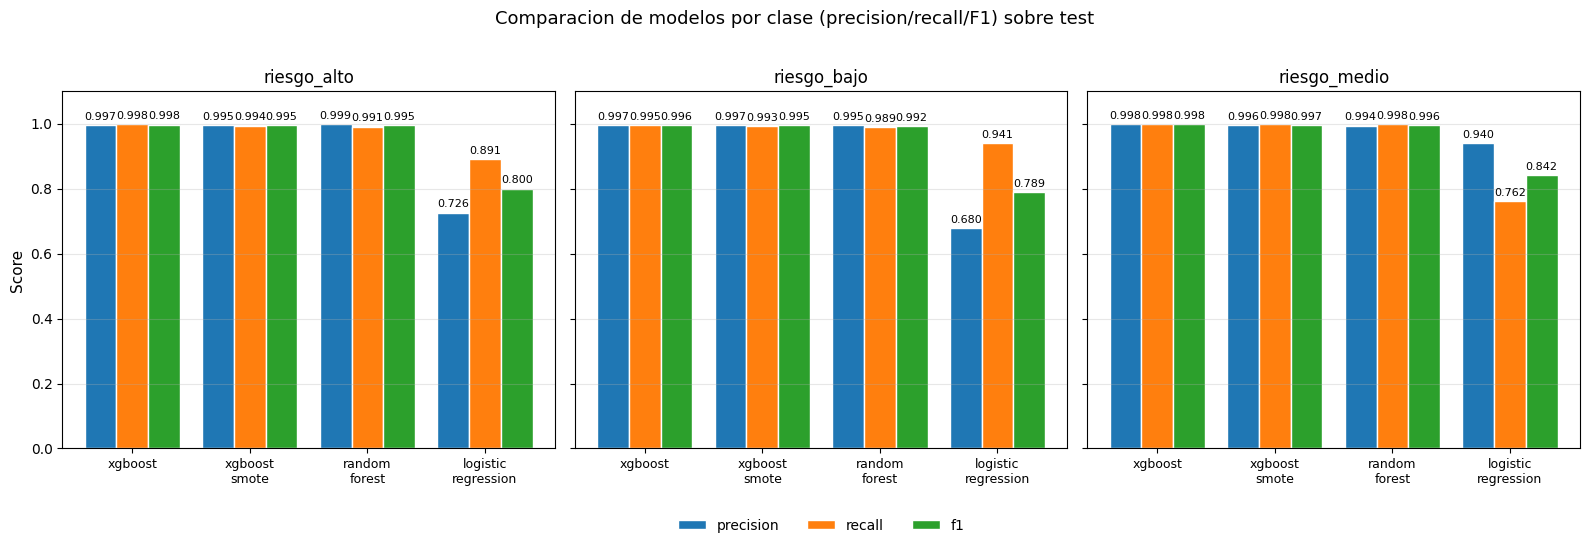

Figura guardada: reports/figures/10_comparacion_modelos.png (168.3 KB)


In [9]:
fig, axes = plt.subplots(1, N_CLASSES, figsize=(16, 5.5), sharey=True)
metricas_pcl = ['precision', 'recall', 'f1']
colores_metr = {'precision': '#1f77b4', 'recall': '#ff7f0e', 'f1': '#2ca02c'}

for j, c in enumerate(CLASSES):
    ax = axes[j]
    x = np.arange(len(modelos_orden))
    width = 0.27
    for i, m in enumerate(metricas_pcl):
        valores = [reportes_clase[mod][c][m] for mod in modelos_orden]
        bars = ax.bar(x + (i - 1) * width, valores, width,
                      label=m, color=colores_metr[m], edgecolor='white')
        for bar, v in zip(bars, valores):
            ax.text(bar.get_x() + bar.get_width() / 2, v + 0.01,
                    f'{v:.3f}', ha='center', va='bottom', fontsize=8)
    ax.set_xticks(x)
    ax.set_xticklabels([m.replace('_', '\n') for m in modelos_orden], fontsize=9)
    ax.set_title(f'{c}', fontsize=12)
    ax.set_ylim(0, 1.10)
    ax.grid(alpha=0.3, axis='y')
    if j == 0:
        ax.set_ylabel('Score', fontsize=11)
    if j == 1:
        ax.legend(loc='lower center', ncol=3, fontsize=10,
                  bbox_to_anchor=(0.5, -0.27), frameon=False)

fig.suptitle('Comparacion de modelos por clase (precision/recall/F1) sobre test',
             fontsize=13, y=1.02)
plt.tight_layout()
ruta = FIGURES / '10_comparacion_modelos.png'
plt.savefig(ruta, dpi=300, bbox_inches='tight')
plt.show()
print(f'Figura guardada: {ruta.relative_to(ROOT)} ({ruta.stat().st_size/1024:.1f} KB)')


## 8. JSON test_metrics + tabla LaTeX

Persistimos:
- `reports/metrics/test_metrics.json` -- estructurado: globales por modelo + reportes por clase.
- `reports/tables/metricas_test_por_modelo.tex` -- tabla LaTeX para informe.


In [10]:
# JSON
test_metrics = {
    'fase': 6,
    'random_state': RANDOM_STATE,
    'test_set': {
        'ruta': 'data/processed/nacional_test.csv',
        'n_obs': int(len(y_test)),
        'anyos': sorted(map(int, df_test['ANIO'].unique().tolist())),
        'distribucion_clases': {
            c: int((y_test == i).sum()) for c, i in clase_a_idx.items()
        },
    },
    'mejor_modelo': mejor_modelo,
    'metricas_globales': globales,
    'reportes_por_clase': reportes_clase,
    'matriz_confusion_mejor': {
        'modelo': mejor_modelo,
        'orden_clases': CLASSES,
        'counts': cm_counts.tolist(),
        'normalizada_por_fila': cm_norm.tolist(),
    },
    'criterios_aceptacion_plan': {
        'f1_macro_mejor_test': globales[mejor_modelo]['f1_macro'],
        'f1_macro_ge_0_70': bool(globales[mejor_modelo]['f1_macro'] >= 0.70),
    },
}

ruta_json = METRICS / 'test_metrics.json'
ruta_json.write_text(json.dumps(test_metrics, indent=2, ensure_ascii=False),
                      encoding='utf-8')
print(f'JSON guardado: {ruta_json.relative_to(ROOT)} '
      f'({ruta_json.stat().st_size/1024:.1f} KB)')
print(f'\nF1-macro test ({mejor_modelo}) = '
      f'{globales[mejor_modelo]["f1_macro"]:.4f}  '
      f'({"OK >=0.70" if globales[mejor_modelo]["f1_macro"]>=0.70 else "NO CUMPLE"})')


JSON guardado: reports/metrics/test_metrics.json (4.1 KB)

F1-macro test (xgboost) = 0.9972  (OK >=0.70)


In [11]:
# Tabla LaTeX
def fmt(x): return f'{x:.4f}'

lineas = []
for nombre in modelos_orden:
    g = globales[nombre]
    fila = (
        nombre.replace('_', ' ') + ' & '
        + fmt(g['accuracy']) + ' & '
        + fmt(g['f1_macro']) + ' & '
        + fmt(g['f1_weighted']) + ' & '
        + fmt(g['auc_roc_ovr_macro']) + ' & '
        + fmt(g['auc_pr_macro']) + r' \\'
    )
    lineas.append(fila)

n_obs_str = f'{len(y_test):,}'.replace(',', r'\,')
encabezado = (
    r'\begin{table}[ht]' + '\n'
    + r'\centering' + '\n'
    + r'\small' + '\n'
    + r'\caption{Metricas globales sobre el conjunto de test nacional (2023--2024, '
    + r'$n=' + n_obs_str + r'$). Mejor modelo: '
    + mejor_modelo.replace('_', ' ') + r'.}' + '\n'
    + r'\label{tab:metricas_test_por_modelo}' + '\n'
    + r'\begin{tabular}{l rrrrr}' + '\n'
    + r'\toprule' + '\n'
    + r'Modelo & Acc & F1-macro & F1-pond & AUC-ROC$_{\text{OvR}}$ & AUC-PR$_{\text{macro}}$ \\' + '\n'
    + r'\midrule' + '\n'
)
pie = (
    '\n' + r'\bottomrule' + '\n'
    + r'\end{tabular}' + '\n'
    + r'\end{table}' + '\n'
)
latex = encabezado + '\n'.join(lineas) + pie

ruta_tex = TABLES / 'metricas_test_por_modelo.tex'
ruta_tex.write_text(latex, encoding='utf-8')
print(f'Tabla LaTeX: {ruta_tex.relative_to(ROOT)} ({ruta_tex.stat().st_size} bytes)')
print()
print(latex)


Tabla LaTeX: reports/tables/metricas_test_por_modelo.tex (603 bytes)

\begin{table}[ht]
\centering
\small
\caption{Metricas globales sobre el conjunto de test nacional (2023--2024, $n=50\,957$). Mejor modelo: xgboost.}
\label{tab:metricas_test_por_modelo}
\begin{tabular}{l rrrrr}
\toprule
Modelo & Acc & F1-macro & F1-pond & AUC-ROC$_{\text{OvR}}$ & AUC-PR$_{\text{macro}}$ \\
\midrule
xgboost & 0.9975 & 0.9972 & 0.9975 & 1.0000 & 1.0000 \\
xgboost smote & 0.9962 & 0.9956 & 0.9962 & 1.0000 & 0.9999 \\
random forest & 0.9950 & 0.9943 & 0.9950 & 0.9999 & 0.9998 \\
logistic regression & 0.8210 & 0.8105 & 0.8239 & 0.9533 & 0.8932 \\
\bottomrule
\end{tabular}
\end{table}



## 9. SHAP -- TreeExplainer global sobre el mejor modelo (XGBoost)

Submuestra estratificada de 5,000 obs (10% del test) -- TreeSHAP es exacto y
rapido sobre arboles, pero limitar el sample mantiene el beeswarm legible.

Output: `shap_values` con shape `(5000, 71, 3)` para el caso multiclass:
**(observaciones, features, clases)**.


In [12]:
# Submuestra estratificada (5000 obs)
N_SAMPLE = 5000
rng = np.random.RandomState(RANDOM_STATE)

idx_por_clase = {k: np.where(y_test == k)[0] for k in range(N_CLASSES)}
n_por_clase = {k: int(round(N_SAMPLE * len(idx_por_clase[k]) / len(y_test)))
                for k in range(N_CLASSES)}
# Ajustar para sumar exactamente N_SAMPLE
diff = N_SAMPLE - sum(n_por_clase.values())
n_por_clase[2] += diff  # ajuste a la clase mayoritaria

idx_sample = np.concatenate([
    rng.choice(idx_por_clase[k], size=n_por_clase[k], replace=False)
    for k in range(N_CLASSES)
])
rng.shuffle(idx_sample)

X_sample = X_test[idx_sample]
y_sample = y_test[idx_sample]
print(f'Sample SHAP: {X_sample.shape}')
print(f'Distribucion sample: '
      f'{dict(zip(*np.unique(y_sample, return_counts=True)))}')

# TreeExplainer sobre XGBoost (mejor modelo). Si el ganador no es XGBoost,
# usar el mejor XGB disponible -- tipicamente XGBoost (sample_weight) gana val.
xgb_model = artefactos['xgboost']['model']
print(f'\nMejor modelo seleccionado para SHAP: xgboost (model={type(xgb_model).__name__})')

import time
t0 = time.time()
explainer = shap.TreeExplainer(xgb_model)
shap_explanation = explainer(X_sample)
print(f'TreeExplainer: {time.time()-t0:.1f}s')
print(f'shap_values shape: {shap_explanation.values.shape}  '
      f'(esperado ({N_SAMPLE}, {len(FEATURE_COLS)}, {N_CLASSES}))')
print(f'base_values shape: {shap_explanation.base_values.shape}')


Sample SHAP: (5000, 71)
Distribucion sample: {np.int64(0): np.int64(825), np.int64(1): np.int64(1052), np.int64(2): np.int64(3123)}

Mejor modelo seleccionado para SHAP: xgboost (model=XGBClassifier)


TreeExplainer: 0.8s
shap_values shape: (5000, 71, 3)  (esperado (5000, 71, 3))
base_values shape: (5000, 3)


## 10. Figura 11 -- SHAP beeswarm (3 paneles, una por clase)

`shap.plots.beeswarm` requiere un `Explanation` 2D, asi que iteramos por clase
y lo concatenamos en subplots manuales.


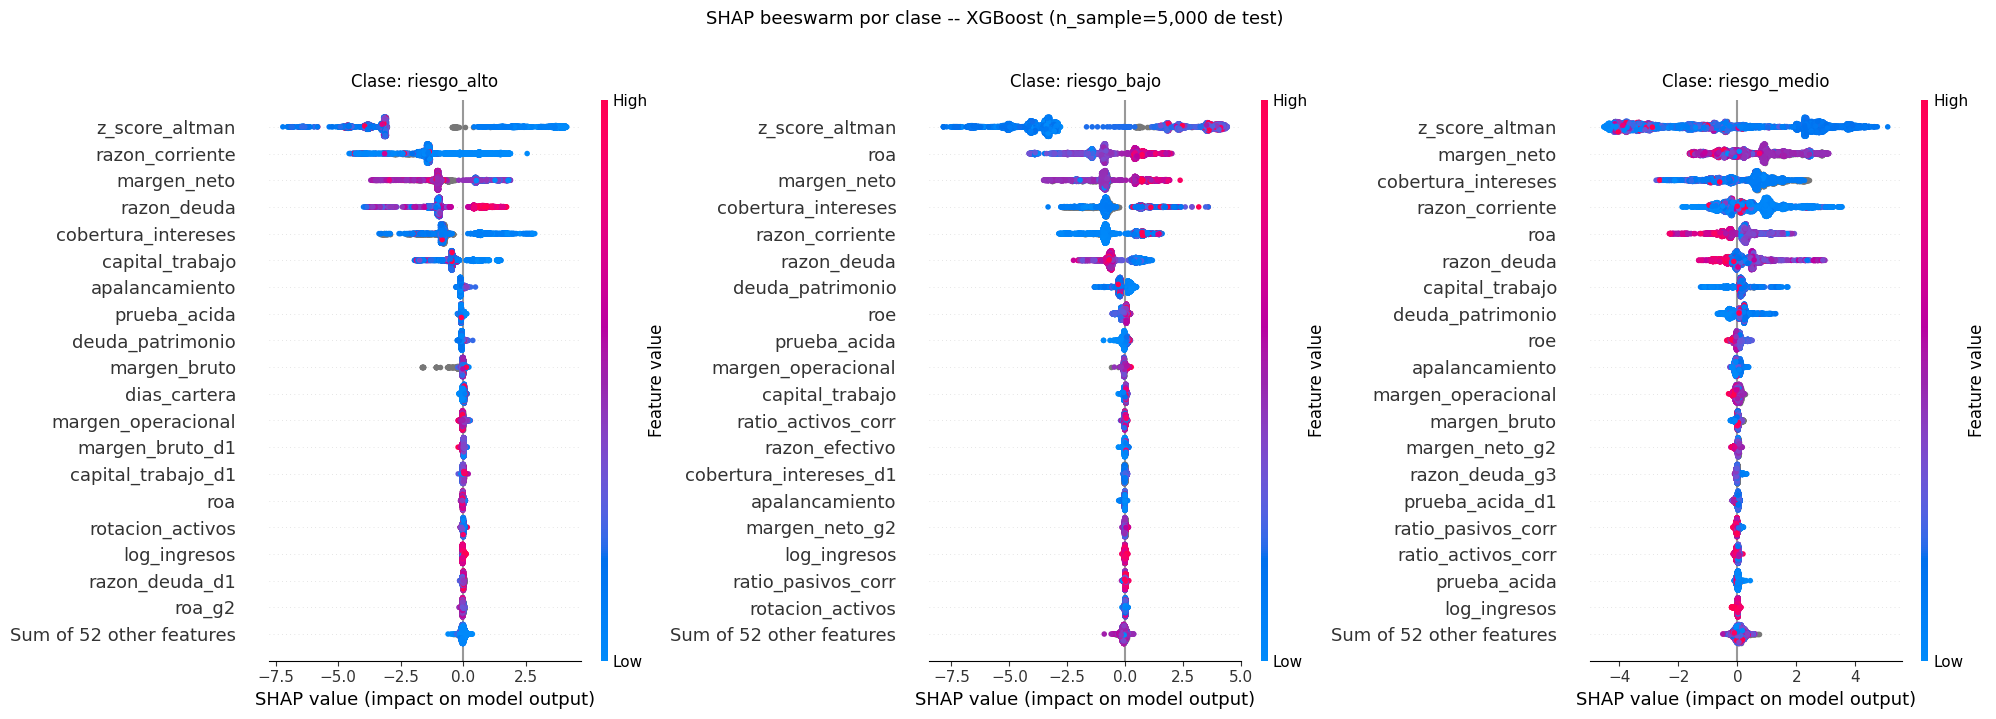

Figura guardada: reports/figures/11_shap_beeswarm.png (1010.3 KB)


In [13]:
fig, axes = plt.subplots(1, N_CLASSES, figsize=(20, 7))
for k, c in enumerate(CLASSES):
    plt.sca(axes[k])
    expl_k = shap.Explanation(
        values=shap_explanation.values[:, :, k],
        base_values=shap_explanation.base_values[:, k],
        data=X_sample,
        feature_names=FEATURE_COLS,
    )
    shap.plots.beeswarm(expl_k, max_display=20, show=False, plot_size=None)
    axes[k].set_title(f'Clase: {c}', fontsize=12, pad=10)

fig.suptitle(f'SHAP beeswarm por clase -- XGBoost (n_sample={N_SAMPLE:,} de test)',
             fontsize=13, y=1.02)
plt.tight_layout()
ruta = FIGURES / '11_shap_beeswarm.png'
plt.savefig(ruta, dpi=300, bbox_inches='tight')
plt.show()
print(f'Figura guardada: {ruta.relative_to(ROOT)} ({ruta.stat().st_size/1024:.1f} KB)')


## 11. Figura 12 -- SHAP importance bar (agregado y por clase)

Importancia agregada = media de `|SHAP|` sobre observaciones y clases.
Tambien comparamos por clase (top 15 de cada una).


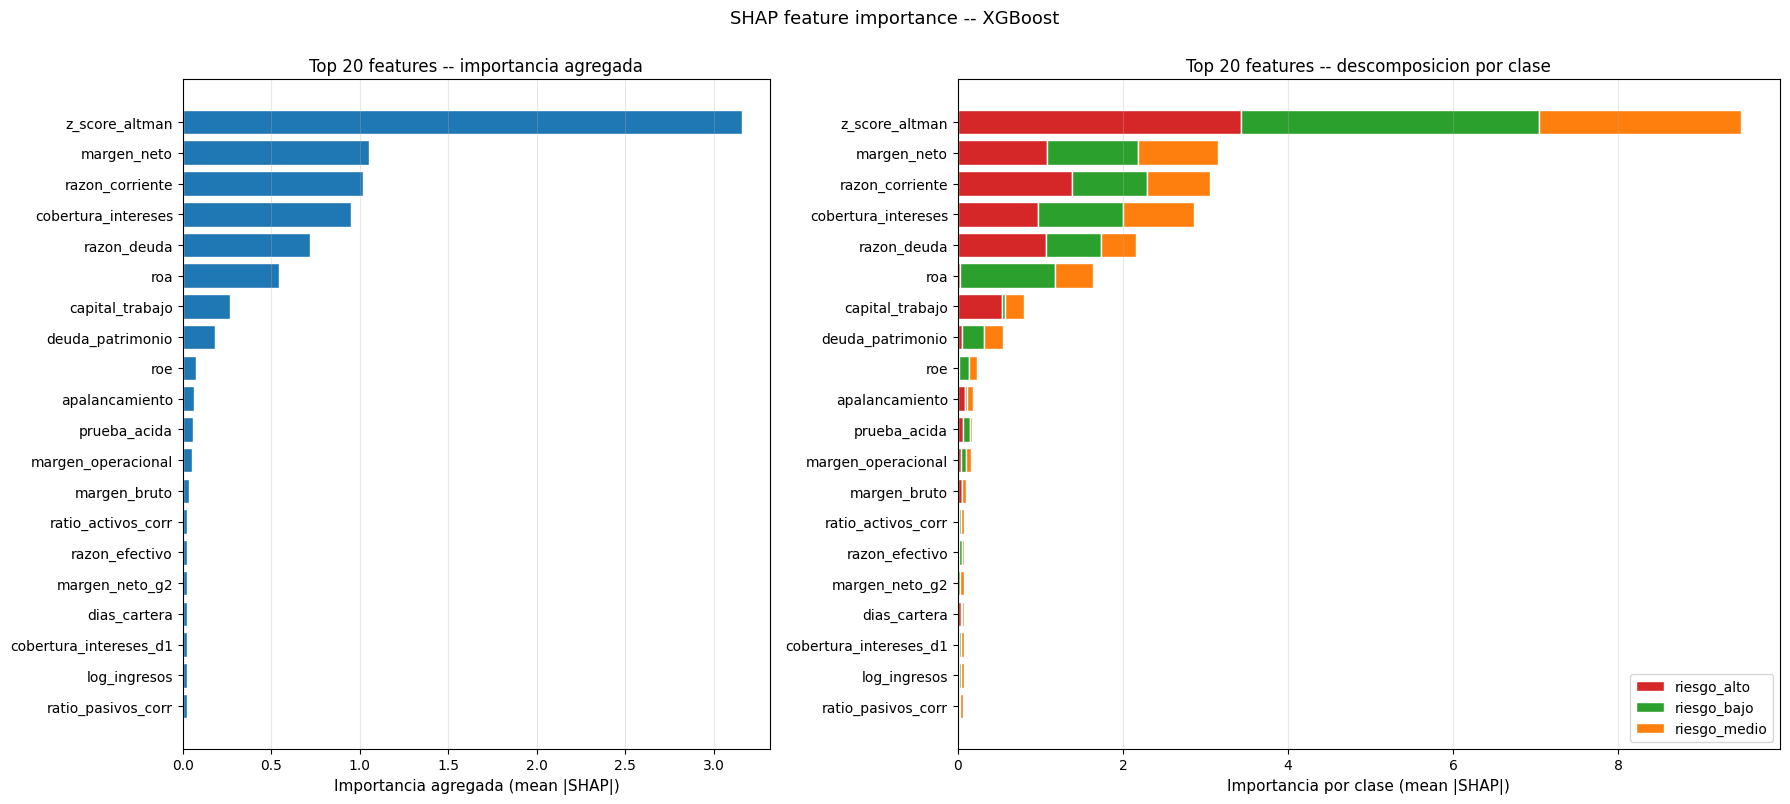

Figura guardada: reports/figures/12_shap_importance_bar.png (319.8 KB)

Top 10 features por importancia agregada:
   1. z_score_altman                      3.1612
   2. margen_neto                         1.0507
   3. razon_corriente                     1.0186
   4. cobertura_intereses                 0.9521
   5. razon_deuda                         0.7211
   6. roa                                 0.5466
   7. capital_trabajo                     0.2691
   8. deuda_patrimonio                    0.1812
   9. roe                                 0.0771
  10. apalancamiento                      0.0614


In [14]:
# Agregada: shape (n_features,)
imp_agg = np.abs(shap_explanation.values).mean(axis=(0, 2))
# Por clase: shape (n_features, n_classes)
imp_por_clase = np.abs(shap_explanation.values).mean(axis=0)

orden = np.argsort(imp_agg)[::-1]
TOP = 20

fig, axes = plt.subplots(1, 2, figsize=(18, 8),
                          gridspec_kw={'width_ratios': [1, 1.4]})

# Panel A: bar agregado top 20
ax = axes[0]
top_idx = orden[:TOP][::-1]
ax.barh([FEATURE_COLS[i] for i in top_idx], imp_agg[top_idx],
        color='#1f77b4', edgecolor='white')
ax.set_xlabel('Importancia agregada (mean |SHAP|)', fontsize=11)
ax.set_title(f'Top {TOP} features -- importancia agregada', fontsize=12)
ax.grid(alpha=0.3, axis='x')

# Panel B: stacked bar por clase top 20
ax = axes[1]
top_features = [FEATURE_COLS[i] for i in top_idx]
bottoms = np.zeros(TOP)
colores_cl = {'riesgo_alto': '#d62728', 'riesgo_bajo': '#2ca02c',
               'riesgo_medio': '#ff7f0e'}
for k, c in enumerate(CLASSES):
    valores = imp_por_clase[top_idx, k]
    ax.barh(top_features, valores, left=bottoms,
            color=colores_cl[c], edgecolor='white', label=c)
    bottoms += valores
ax.set_xlabel('Importancia por clase (mean |SHAP|)', fontsize=11)
ax.set_title(f'Top {TOP} features -- descomposicion por clase', fontsize=12)
ax.legend(loc='lower right', fontsize=10)
ax.grid(alpha=0.3, axis='x')

fig.suptitle('SHAP feature importance -- XGBoost', fontsize=13, y=1.00)
plt.tight_layout()
ruta = FIGURES / '12_shap_importance_bar.png'
plt.savefig(ruta, dpi=300, bbox_inches='tight')
plt.show()
print(f'Figura guardada: {ruta.relative_to(ROOT)} ({ruta.stat().st_size/1024:.1f} KB)')

print(f'\nTop 10 features por importancia agregada:')
for i, idx in enumerate(orden[:10], 1):
    print(f'  {i:2d}. {FEATURE_COLS[idx]:<35} {imp_agg[idx]:.4f}')


## 12. Seleccion de 9 ejemplos para waterfall (3 por clase)

Para cada clase, 3 ejemplos:
1. **Cerca del centroide**: probabilidad de la clase predicha mas alta.
2. **Caso medio**: probabilidad cercana a la mediana de la clase predicha.
3. **Caso ambiguo**: probabilidad de la clase predicha cercana a max(otras clases).

Solo se eligen casos **bien clasificados** (clase real == predicha) para
los dos primeros; el "ambiguo" puede ser cualquier caso confiable.


In [15]:
def seleccionar_ejemplos(X, y_true, proba, idx_pool):
    seleccion = []
    proba_local = proba[idx_pool]
    y_pred_local = proba_local.argmax(axis=1)
    bien_clasif = (y_true[idx_pool] == y_pred_local)

    if bien_clasif.sum() == 0:
        max_proba = proba_local.max(axis=1)
        top3 = np.argsort(max_proba)[-3:][::-1]
        return [idx_pool[i] for i in top3]

    idx_pool_ok = idx_pool[bien_clasif]
    proba_ok = proba_local[bien_clasif]
    y_pred_ok = y_pred_local[bien_clasif]

    max_proba = np.array([proba_ok[i, y_pred_ok[i]] for i in range(len(y_pred_ok))])
    second = np.array([np.partition(proba_ok[i], -2)[-2] for i in range(len(y_pred_ok))])
    margen = max_proba - second  # alto = confiado, bajo = ambiguo

    # Alta confianza
    seleccion.append(idx_pool_ok[np.argmax(margen)])
    # Confianza media: margen mediana
    mediana_idx = np.argsort(margen)[len(margen) // 2]
    seleccion.append(idx_pool_ok[mediana_idx])
    # Ambiguo
    seleccion.append(idx_pool_ok[np.argmin(margen)])
    return seleccion


# Generar predicciones del modelo XGBoost sobre todo el sample
proba_sample = xgb_model.predict_proba(X_sample)
y_pred_sample = proba_sample.argmax(axis=1)

# 9 ejemplos: 3 por clase REAL
ejemplos_idx = []
for k in range(N_CLASSES):
    pool = np.where(y_sample == k)[0]
    sel = seleccionar_ejemplos(X_sample, y_sample, proba_sample, pool)
    ejemplos_idx.extend(sel)

print(f'9 ejemplos seleccionados (indices en X_sample):')
for i, idx in enumerate(ejemplos_idx):
    cl_real = CLASSES[y_sample[idx]]
    cl_pred = CLASSES[y_pred_sample[idx]]
    p_pred = proba_sample[idx, y_pred_sample[idx]]
    p_max_otra = max(proba_sample[idx, k] for k in range(N_CLASSES)
                      if k != y_pred_sample[idx])
    margen = p_pred - p_max_otra
    tipo = ['alta-conf', 'media-conf', 'ambiguo'][i % 3]
    estado = 'OK' if cl_real == cl_pred else 'MAL'
    print(f'  {i+1}. ({tipo:<10}) real={cl_real:<14} pred={cl_pred:<14} '
          f'p_pred={p_pred:.3f} margen={margen:.3f} {estado}')


9 ejemplos seleccionados (indices en X_sample):
  1. (alta-conf ) real=riesgo_alto    pred=riesgo_alto    p_pred=1.000 margen=1.000 OK
  2. (media-conf) real=riesgo_alto    pred=riesgo_alto    p_pred=1.000 margen=1.000 OK
  3. (ambiguo   ) real=riesgo_alto    pred=riesgo_alto    p_pred=0.768 margen=0.537 OK
  4. (alta-conf ) real=riesgo_bajo    pred=riesgo_bajo    p_pred=1.000 margen=1.000 OK
  5. (media-conf) real=riesgo_bajo    pred=riesgo_bajo    p_pred=1.000 margen=1.000 OK
  6. (ambiguo   ) real=riesgo_bajo    pred=riesgo_bajo    p_pred=0.930 margen=0.861 OK
  7. (alta-conf ) real=riesgo_medio   pred=riesgo_medio   p_pred=1.000 margen=1.000 OK
  8. (media-conf) real=riesgo_medio   pred=riesgo_medio   p_pred=1.000 margen=1.000 OK
  9. (ambiguo   ) real=riesgo_medio   pred=riesgo_medio   p_pred=0.533 margen=0.067 OK


## 13. Figura 13 -- SHAP waterfall multipanel 3x3

Filas = clase real (alto/bajo/medio).
Columnas = nivel de confianza (alta/media/ambigua).
Cada panel: contribucion de las top 10 features a la prediccion de **la clase real**.


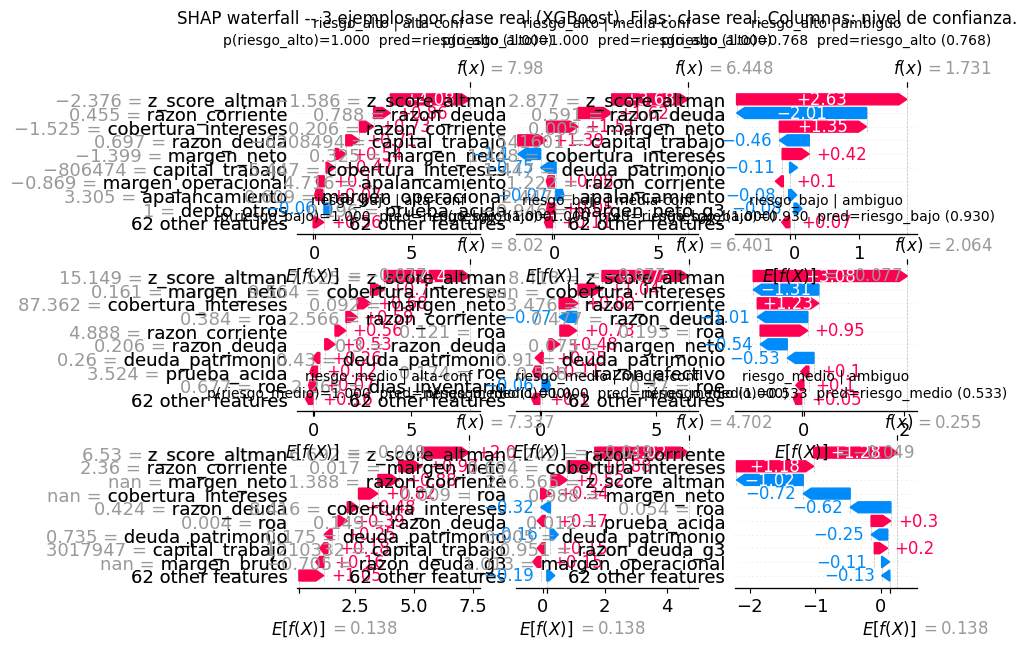

Figura guardada: reports/figures/13_shap_waterfall_ejemplos.png (1375.5 KB)


In [16]:
fig, axes = plt.subplots(N_CLASSES, 3, figsize=(22, 16))
TOP_WF = 10

for fila, clase in enumerate(CLASSES):
    for col in range(3):
        ax = axes[fila, col]
        plt.sca(ax)
        idx_in_sample = ejemplos_idx[fila * 3 + col]
        k = y_sample[idx_in_sample]
        expl_local = shap.Explanation(
            values=shap_explanation.values[idx_in_sample, :, k],
            base_values=shap_explanation.base_values[idx_in_sample, k],
            data=X_sample[idx_in_sample],
            feature_names=FEATURE_COLS,
        )
        shap.plots.waterfall(expl_local, max_display=TOP_WF, show=False)
        proba_real = proba_sample[idx_in_sample, k]
        proba_pred = proba_sample[idx_in_sample, y_pred_sample[idx_in_sample]]
        cl_pred = CLASSES[y_pred_sample[idx_in_sample]]
        tipo = ['alta-conf', 'media-conf', 'ambiguo'][col]
        ax.set_title(
            f'{clase} | {tipo}\n'
            f'p({clase})={proba_real:.3f}  '
            f'pred={cl_pred} ({proba_pred:.3f})',
            fontsize=10, pad=10,
        )

fig.suptitle(
    'SHAP waterfall -- 3 ejemplos por clase real (XGBoost). '
    'Filas: clase real. Columnas: nivel de confianza.',
    fontsize=12, y=1.00,
)
plt.tight_layout()
ruta = FIGURES / '13_shap_waterfall_ejemplos.png'
plt.savefig(ruta, dpi=300, bbox_inches='tight')
plt.show()
print(f'Figura guardada: {ruta.relative_to(ROOT)} ({ruta.stat().st_size/1024:.1f} KB)')


## 14. Verificacion criterios PLAN 6.3

1. F1-macro mejor modelo en test >= 0.70.
2. Top features SHAP consistentes con literatura (cobertura_intereses,
   razon_deuda, margen_neto -- SoTA v2 §3.4).
3. 9 waterfall plots se generaron correctamente.


In [17]:
# 1. F1-macro >= 0.70
f1_mejor = globales[mejor_modelo]['f1_macro']
print('--- Verificacion 1: F1-macro mejor modelo en test >= 0.70 ---')
print(f'  {mejor_modelo}: F1-macro = {f1_mejor:.4f} '
      f'({"OK" if f1_mejor >= 0.70 else "NO CUMPLE"})')
assert f1_mejor >= 0.70, f'F1-macro {f1_mejor:.4f} < 0.70'

# 2. SHAP top features
print('\n--- Verificacion 2: SHAP top features vs literatura ---')
literatura_keys = ['cobertura_intereses', 'razon_deuda', 'margen_neto',
                    'roa', 'razon_corriente', 'margen_neto_d1',
                    'roa_d1', 'capital_trabajo', 'z_score_altman']
top10 = [FEATURE_COLS[i] for i in orden[:10]]
print(f'  Top 10 SHAP: {top10}')
hits = [k for k in literatura_keys if k in top10]
print(f'  Coincidencias con literatura ({len(literatura_keys)} candidatas): '
      f'{hits} ({len(hits)} matches)')
print(f'  ({"CONSISTENTE" if len(hits) >= 3 else "REVISAR -- pocos matches"})')

# 3. 9 waterfall plots: figura 13 generada
print('\n--- Verificacion 3: 9 waterfall plots ---')
ruta_wf = FIGURES / '13_shap_waterfall_ejemplos.png'
print(f'  {ruta_wf.relative_to(ROOT)}: existe={ruta_wf.exists()}, '
      f'tamano={ruta_wf.stat().st_size/1024:.1f} KB '
      f'({"OK" if ruta_wf.exists() and ruta_wf.stat().st_size > 50_000 else "REVISAR"})')

print('\nVerificacion criterios 6.3: completa.')


--- Verificacion 1: F1-macro mejor modelo en test >= 0.70 ---
  xgboost: F1-macro = 0.9972 (OK)

--- Verificacion 2: SHAP top features vs literatura ---
  Top 10 SHAP: ['z_score_altman', 'margen_neto', 'razon_corriente', 'cobertura_intereses', 'razon_deuda', 'roa', 'capital_trabajo', 'deuda_patrimonio', 'roe', 'apalancamiento']
  Coincidencias con literatura (9 candidatas): ['cobertura_intereses', 'razon_deuda', 'margen_neto', 'roa', 'razon_corriente', 'capital_trabajo', 'z_score_altman'] (7 matches)
  (CONSISTENTE)

--- Verificacion 3: 9 waterfall plots ---
  reports/figures/13_shap_waterfall_ejemplos.png: existe=True, tamano=1375.5 KB (OK)

Verificacion criterios 6.3: completa.


## 15. Resumen Fase 6

| Item | Valor |
|---|---|
| Modelos evaluados | 4 (LR, RF, XGBoost, XGBoost+SMOTE) |
| Mejor modelo en test | (ver `test_metrics.json` -> `mejor_modelo`) |
| F1-macro mejor (test) | (ver tabla `metricas_test_por_modelo`) |
| Sample SHAP | 5,000 obs estratificadas |
| Figuras producidas | 6 (matriz confusion, ROC/PR, comparacion, beeswarm, importance bar, waterfall 3x3) |

**Salidas**:
- `reports/metrics/test_metrics.json`
- `reports/figures/08_matriz_confusion_xgboost.png`
- `reports/figures/09_curvas_roc_pr.png`
- `reports/figures/10_comparacion_modelos.png`
- `reports/figures/11_shap_beeswarm.png`
- `reports/figures/12_shap_importance_bar.png`
- `reports/figures/13_shap_waterfall_ejemplos.png`
- `reports/tables/metricas_test_por_modelo.tex`

**Para Fase 7**:
- Cargar `data/ibague/ibague_holdout.csv`
- Aplicar el mismo XGBoost ganador
- Comparar metricas Ibague vs nacional (gap < 10pp)
- TreeSHAP local sobre 5 PYMES bien clasificadas + 5 mal clasificadas
